In [46]:
! pip install "granite-tsfm[notebooks]==0.3.1"
! pip install gdown

Python(54311) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


Python(54317) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [47]:
import math
import os
import joblib

import numpy as np
import pandas as pd
import torch
import evaluate
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import Subset
from transformers import set_seed

import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score

from tsfm_public.models.tspulse import TSPulseForReconstruction
from tsfm_public.toolkit.time_series_preprocessor import (
    TimeSeriesPreprocessor,
    get_datasets,
)

## Load data from carOBD

In [48]:
path = "/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/data/carOBD/obdiidata" 
time_col = 'ENGINE_RUN_TINE ()'

df_list = []
for file in os.listdir(path):
  if file.endswith('.csv'):
    df = pd.read_csv(f'{path}/{file}', index_col=False)
    df['filename'] = file
    df_list.append(df)

print(f'{len(df_list)} files loaded out of {len([f for f in os.listdir(path) if f.endswith(".csv")])}')


129 files loaded out of 129


## Remove zero-variance columns

In [49]:
def remove_zero_variance_columns(df: pd.DataFrame) -> pd.DataFrame:
  """
  Compute std of each std-computable column (numeric only)
  """
  std_df = df.std(numeric_only=True)

  zero_variance_cols = std_df[std_df == 0].index.tolist()
  print(f'{len(zero_variance_cols)} columns with zero variance')

  if len(zero_variance_cols) > 0:
    df = df.drop(columns=zero_variance_cols)

  return df

## Handle missing Timestamps and duplicates

In [50]:
def mean_fill_missing_timestamps_and_remove_duplicates(df: pd.DataFrame) -> pd.DataFrame:
  """
  Remove duplicate timestamps by averaging all numeric columns for each unique timestamp.
  This preserves the overall statistics while removing duplicate entries.
  
  Note: The time column itself is not averaged (it becomes the group key).
  Only numeric columns are averaged when multiple rows share the same timestamp.
  """
  df = df.groupby(time_col, as_index=False).mean(numeric_only=True)
  return df

## Inject Anomalies

In [51]:
from typing import Tuple, Dict, Optional, List

def create_realistic_fault_data(
    normal_data: np.ndarray, 
    fault_percentage: float = 0.2,
    random_state: Optional[int] = None,
    fault_types: Optional[List[str]] = None
) -> Tuple[np.ndarray, np.ndarray, Dict]:
    if fault_types is None:
        fault_types = ['coolant_bias', 'coolant_drift', 'coolant_stuck', 'rpm_bias', 'multi_sensor']
    
    if random_state is not None:
        np.random.seed(random_state)
    
    n_samples = len(normal_data)
    n_faults = int(n_samples * fault_percentage)
    
    fault_labels = np.zeros(n_samples, dtype=int)
    fault_indices = np.random.choice(n_samples, n_faults, replace=False)
    fault_labels[fault_indices] = 1
    fault_features = normal_data.copy()
    
    fault_type_list = [None] * n_samples
    original_values = [[] for _ in range(n_samples)]
    modified_values = [[] for _ in range(n_samples)]
    
    for idx in fault_indices:
        fault_type = np.random.choice(fault_types)
        fault_type_list[idx] = fault_type
        
        if fault_type == 'coolant_bias':
            bias_amount = np.random.uniform(40, 80) * np.random.choice([-1, 1])
            original_val = fault_features[idx, 0]
            fault_features[idx, 0] += bias_amount
            original_values[idx].append(original_val)
            modified_values[idx].append(fault_features[idx, 0])
        
        elif fault_type == 'coolant_drift':
            drift_factor = np.random.uniform(0.6, 1.4)
            original_val = fault_features[idx, 0]
            fault_features[idx, 0] *= drift_factor
            original_values[idx].append(original_val)
            modified_values[idx].append(fault_features[idx, 0])
            
            if fault_features.shape[1] > 1:
                rpm_factor = np.random.uniform(0.7, 1.3)
                original_rpm = fault_features[idx, 1]
                fault_features[idx, 1] *= rpm_factor
                original_values[idx].append(original_rpm)
                modified_values[idx].append(fault_features[idx, 1])
        
        elif fault_type == 'coolant_stuck':
            stuck_temp = np.random.uniform(10, 150)
            original_val = fault_features[idx, 0]
            fault_features[idx, 0] = stuck_temp
            original_values[idx].append(original_val)
            modified_values[idx].append(stuck_temp)
        
        elif fault_type == 'rpm_bias':
            rpm_bias = np.random.uniform(300, 1000) * np.random.choice([-1, 1])
            if fault_features.shape[1] > 1:
                original_rpm = fault_features[idx, 1]
                fault_features[idx, 1] += rpm_bias
                original_values[idx].append(original_rpm)
                modified_values[idx].append(fault_features[idx, 1])
        
        elif fault_type == 'multi_sensor':
            degradation_factor = np.random.uniform(0.5, 1.5)
            original_vals_copy = fault_features[idx].copy()
            fault_features[idx] *= degradation_factor
            noise_level = np.random.uniform(0.15, 0.3)
            fault_features[idx] += np.random.normal(0, noise_level, fault_features.shape[1])
            
            for col_idx in range(fault_features.shape[1]):
                original_values[idx].append(original_vals_copy[col_idx])
                modified_values[idx].append(fault_features[idx, col_idx])
    
    fault_info = {
        'fault_types': fault_type_list,
        'original_values': original_values,
        'modified_values': modified_values,
        'n_faults': n_faults,
        'fault_percentage': fault_percentage
    }
    
    return fault_features, fault_labels, fault_info

## Process Data

In [52]:
target_columns = [
    'COOLANT_TEMPERATURE ()',
    'ENGINE_RPM ()',
    'VEHICLE_SPEED ()',
    'THROTTLE ()',
    'ENGINE_LOAD ()',
    'INTAKE_MANIFOLD_PRESSURE ()',
]

print("Processing all files and combining into single DataFrame...")
dfs = []
skipped_files = []

for drive_idx, df in enumerate(df_list):
    df_clean = mean_fill_missing_timestamps_and_remove_duplicates(df)
    
    missing_cols = [col for col in target_columns if col not in df_clean.columns]
    if missing_cols:
        print(f"⚠️  File {drive_idx} missing columns: {missing_cols}")
        skipped_files.append(drive_idx)
        continue
    
    if time_col not in df_clean.columns:
        print(f"⚠️  File {drive_idx} missing timestamp column: {time_col}")
        skipped_files.append(drive_idx)
        continue
    
    # Add drive_id to identify each time series
    df_clean['drive_id'] = drive_idx

    required_cols = [time_col, 'drive_id'] + target_columns
    df_clean = df_clean[required_cols].copy()
    
    if not pd.api.types.is_numeric_dtype(df_clean[time_col]):
        df_clean[time_col] = pd.to_numeric(df_clean[time_col], errors='coerce')
    
    df_clean = df_clean.dropna(subset=[time_col] + target_columns)
    
    if len(df_clean) == 0:
        print(f"⚠️  File {drive_idx} has no valid data after cleaning")
        skipped_files.append(drive_idx)
        continue
    
    dfs.append(df_clean)
    print(f"✓ File {drive_idx}: {len(df_clean)} samples")

# Combine all dataframes
if len(dfs) == 0:
    raise ValueError("No valid data files found!")

data = pd.concat(dfs, ignore_index=True)

print(f"\n{'='*60}")
print(f"Data Summary:")
print(f"{'='*60}")
print(f"Total files processed: {len(dfs)}")
print(f"Skipped files: {len(skipped_files)}")
print(f"Total rows: {len(data):,}")
print(f"Unique drives: {data['drive_id'].nunique()}")
print(f"Columns: {list(data.columns)}")
print(f"\nData shape: {data.shape}")

Processing all files and combining into single DataFrame...
✓ File 0: 617 samples
✓ File 1: 722 samples
✓ File 2: 512 samples
✓ File 3: 1111 samples
✓ File 4: 350 samples
✓ File 5: 397 samples
✓ File 6: 619 samples
✓ File 7: 626 samples
✓ File 8: 957 samples
✓ File 9: 349 samples
✓ File 10: 504 samples
✓ File 11: 265 samples
✓ File 12: 368 samples
✓ File 13: 1041 samples
✓ File 14: 1482 samples
✓ File 15: 343 samples
✓ File 16: 837 samples
✓ File 17: 640 samples
✓ File 18: 1099 samples
✓ File 19: 2039 samples
✓ File 20: 576 samples
✓ File 21: 1029 samples
✓ File 22: 346 samples
✓ File 23: 885 samples
✓ File 24: 297 samples
✓ File 25: 215 samples
✓ File 26: 656 samples
✓ File 27: 1176 samples
✓ File 28: 1646 samples
✓ File 29: 305 samples
✓ File 30: 198 samples
✓ File 31: 516 samples
✓ File 32: 328 samples
✓ File 33: 762 samples
✓ File 34: 311 samples
✓ File 35: 519 samples
✓ File 36: 1259 samples
✓ File 37: 903 samples
✓ File 38: 1591 samples
✓ File 39: 755 samples
✓ File 40: 474 sampl

## Data Split and Fault Injection

In [53]:
from torch.utils.data import DataLoader, Dataset

data['drive_id'] = data['drive_id'].astype(str)
all_drive_ids = data['drive_id'].unique()
train_ids = all_drive_ids[:int(0.7 * len(all_drive_ids))]
val_ids = all_drive_ids[int(0.7 * len(all_drive_ids)):int(0.85 * len(all_drive_ids))]
test_ids = all_drive_ids[int(0.85 * len(all_drive_ids)):]

train_data = data[data['drive_id'].isin(train_ids)]
val_data = data[data['drive_id'].isin(val_ids)]
test_data = data[data['drive_id'].isin(test_ids)]

tsp = TimeSeriesPreprocessor(
    timestamp_column=time_col,
    id_columns=['drive_id'],
    target_columns=target_columns,
    control_columns=[],
    context_length=512,
    prediction_length=96,
    scaling=True,
    scaling_id_columns=[],
    scaling_type="standard"
)

tsp = tsp.train(train_data)

def inject_faults_into_test_set(df_clean, target_columns, fault_percentage=0.15, random_state=42):
    df_faulty = df_clean.copy()
    numeric_cols = [col for col in target_columns if col in df_faulty.columns]
    data_array = df_faulty[numeric_cols].values
    
    fault_features, fault_labels, _ = create_realistic_fault_data(
        normal_data=data_array,
        fault_percentage=fault_percentage,
        random_state=random_state
    )
    
    df_faulty[numeric_cols] = fault_features
    df_faulty['is_anomaly'] = fault_labels
    return df_faulty, fault_labels

test_data_faulty, test_labels = inject_faults_into_test_set(test_data, target_columns, 0.20, 42)

class FilteredForecastDataset(Dataset):
    """Wrapper that filters ForecastDFDataset to only tensor keys"""
    def __init__(self, forecast_dataset):
        self.dataset = forecast_dataset
        # Only keep keys needed for TSPulseForReconstruction
        self.keys_to_keep = ['past_values', 'past_observed_mask']
    
    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self, idx):
        sample = self.dataset[idx]
        # Filter to only tensor-compatible keys
        filtered = {k: v for k, v in sample.items() if k in self.keys_to_keep}
        return filtered


dset_train, _, _ = get_datasets(
    tsp,
    train_data,
    split_config={"train": 1.0, "test": 0.0},
)

dset_val, _, _ = get_datasets(
    tsp,
    val_data,
    split_config={"train": 1.0, "test": 0.0},
)

dset_test, _, _ = get_datasets(
    tsp,
    test_data_faulty,
    split_config={"train": 1.0, "test": 0.0},
)

dset_train = FilteredForecastDataset(dset_train)
dset_val = FilteredForecastDataset(dset_val)
dset_test = FilteredForecastDataset(dset_test)

print(f"Train: {len(dset_train)} windows (clean)")
print(f"Val: {len(dset_val)} windows (with faults)")
print(f"Test: {len(dset_test)} windows (with faults)")


Train: 13641 windows (clean)
Val: 3180 windows (with faults)
Test: 1574 windows (with faults)


## Metrics

In [54]:
from evaluate import load

metric = load("f1")

## Model Init

In [55]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TSPulseForReconstruction.from_pretrained(
    "ibm-granite/granite-timeseries-tspulse-r1",
    revision="main",
    num_input_channels=tsp.num_input_channels
)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-2)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
num_epochs = 100

## Train


In [ ]:
from tqdm import tqdm
from transformers import default_data_collator
import torch

set_seed(42)

train_loader = DataLoader(
    dset_train,
    batch_size=64,
    shuffle=True,
    collate_fn=default_data_collator,
    num_workers=0,
)

val_loader = DataLoader(
    dset_val,
    batch_size=64,
    shuffle=False,
    collate_fn=default_data_collator,
    num_workers=0,
)

best_val_loss = float('inf')
best_epoch = 0
patience = 5
patience_counter = 0

training_history = {
    'train_loss': [],
    'val_loss': []
}

for epoch in range(num_epochs):
    # -------------------------
    # Train
    # -------------------------
    model.train()
    train_loss = 0.0
    n_train_batches = 0
    
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
    
    for batch in train_pbar:
        past_values = batch["past_values"].to(device)
        past_observed_mask = batch["past_observed_mask"].to(device)

        optimizer.zero_grad()

        outputs = model(
            past_values=past_values,
            past_observed_mask=past_observed_mask,
            return_loss=True,
        )
        loss = outputs.loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()

        train_loss += loss.item()
        n_train_batches += 1
        
        # Update progress bar
        train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_train_loss = train_loss / max(n_train_batches, 1)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()
    val_loss = 0.0
    n_val_batches = 0
    
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")

    with torch.no_grad():
        for batch in val_pbar:
            past_values = batch["past_values"].to(device)
            past_observed_mask = batch["past_observed_mask"].to(device)

            outputs = model(
                past_values=past_values,
                past_observed_mask=past_observed_mask,
                return_loss=True,
            )
            loss = outputs.loss

            val_loss += loss.item()
            n_val_batches += 1
            
            val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_val_loss = val_loss / max(n_val_batches, 1)
    
    # Record history
    training_history['train_loss'].append(avg_train_loss)
    training_history['val_loss'].append(avg_val_loss)

    print(f"\nEpoch {epoch+1}/{num_epochs} | train_loss={avg_train_loss:.4f} | val_loss={avg_val_loss:.4f}")

    # Save best model and early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        patience_counter = 0
        
        # Save model
        model.save_pretrained("./tspulse_obd_finetuned")
        print(f"✓ Saved best model (epoch {best_epoch}, val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"No improvement. Patience: {patience_counter}/{patience}")
        
        if patience_counter >= patience:
            print(f"\n⚠ Early stopping triggered at epoch {epoch+1}")
            break

print("\n✓ Training complete!")
print(f"Best model from epoch {best_epoch} with val_loss={best_val_loss:.4f}")

Epoch 1/100 [Val]: 100%|██████████| 50/50 [00:35<00:00,  1.41it/s, loss=0.9945]



Epoch 1/100 | train_loss=1.1684 | val_loss=1.1524
✓ Saved best model (epoch 1, val_loss=1.1524)


Epoch 2/100 [Val]: 100%|██████████| 50/50 [00:14<00:00,  3.40it/s, loss=0.9833]



Epoch 2/100 | train_loss=1.1633 | val_loss=1.1555
No improvement. Patience: 1/5


Epoch 3/100 [Val]: 100%|██████████| 50/50 [00:15<00:00,  3.23it/s, loss=0.9744]


...

Epoch 8/100 [Val]: 100%|██████████| 50/50 [00:15<00:00,  3.17it/s, loss=0.9828]



Epoch 8/100 | train_loss=1.1600 | val_loss=1.1440
No improvement. Patience: 3/5


Epoch 9/100 [Val]: 100%|██████████| 50/50 [00:15<00:00,  3.21it/s, loss=0.9870]



Epoch 9/100 | train_loss=1.1619 | val_loss=1.1366
✓ Saved best model (epoch 9, val_loss=1.1366)


Epoch 10/100 [Train]:  88%|████████▊ | 189/214 [04:32<00:41,  1.66s/it, loss=1.1053]

In [ ]:
def plot_detection_results(
    data_df,
    timestamps,
    true_labels,
    predictions,
    scores,
    threshold,
    value_column="COOLANT_TEMPERATURE ()",
    title="Anomaly Detection Results",
    figsize=(16, 6)
):
    """
    Plot time series with color-coded detection results
    
    Args:
        data_df: DataFrame containing sensor values
        timestamps: Array of timestamps
        true_labels: Ground truth labels (0=normal, 1=anomaly)
        predictions: Model predictions (0=normal, 1=anomaly)
        scores: Anomaly scores
        threshold: Decision threshold
        value_column: Column name to plot
        title: Plot title
        figsize: Figure size tuple
    """
    # Extract values for the specified column
    if isinstance(data_df, pd.DataFrame):
        values = data_df[value_column].values
    else:
        raise ValueError("data_df must be a pandas DataFrame")
    
    # Compute metrics
    precision = precision_score(true_labels, predictions, zero_division=0)
    recall = recall_score(true_labels, predictions, zero_division=0)
    f1 = f1_score(true_labels, predictions, zero_division=0)
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, height_ratios=[3, 1])
    
    # === TOP PLOT: Time series with detection results ===
    ax1.plot(timestamps, values, color='gray', alpha=0.5, linewidth=1, label='Signal')
    
    # True Positives (correctly detected anomalies)
    tp_mask = (true_labels == 1) & (predictions == 1)
    if tp_mask.any():
        ax1.scatter(timestamps[tp_mask], values[tp_mask], 
                    color='green', s=60, marker='o', label=f'True Positive ({tp_mask.sum()})', 
                    zorder=5, edgecolors='darkgreen', linewidths=1.5)
    
    # False Positives (false alarms)
    fp_mask = (true_labels == 0) & (predictions == 1)
    if fp_mask.any():
        ax1.scatter(timestamps[fp_mask], values[fp_mask], 
                    color='red', s=60, marker='x', label=f'False Positive ({fp_mask.sum()})', 
                    zorder=5, linewidths=2)
    
    # False Negatives (missed anomalies)
    fn_mask = (true_labels == 1) & (predictions == 0)
    if fn_mask.any():
        ax1.scatter(timestamps[fn_mask], values[fn_mask], 
                    color='orange', s=100, marker='*', label=f'False Negative ({fn_mask.sum()})', 
                    zorder=5, edgecolors='darkorange', linewidths=1.5)
    
    ax1.set_ylabel(value_column, fontsize=11)
    ax1.set_title(f"{title}\nPrecision={precision:.3f} | Recall={recall:.3f} | F1={f1:.3f}", 
                  fontsize=12, fontweight='bold')
    ax1.legend(loc='upper right', fontsize=9)
    ax1.grid(True, alpha=0.3)
    
    # === BOTTOM PLOT: Anomaly scores with threshold ===
    ax2.plot(timestamps, scores, color='purple', alpha=0.7, linewidth=1, label='Anomaly Score')
    ax2.axhline(y=threshold, color='red', linestyle='--', linewidth=2, 
                alpha=0.7, label=f'Threshold={threshold:.4f}')
    
    # Shade detected anomalies
    ax2.fill_between(timestamps, 0, scores, where=(predictions == 1), 
                     color='red', alpha=0.2, label='Detected Anomalies')
    
    ax2.set_xlabel('Time', fontsize=11)
    ax2.set_ylabel('Score', fontsize=11)
    ax2.legend(loc='upper right', fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n{'='*60}")
    print(f"Detection Summary for {value_column}")
    print(f"{'='*60}")
    print(f"Total points: {len(true_labels)}")
    print(f"True anomalies: {true_labels.sum()} ({true_labels.mean()*100:.1f}%)")
    print(f"Detected anomalies: {predictions.sum()} ({predictions.mean()*100:.1f}%)")
    print(f"\nTrue Positives:  {tp_mask.sum()}")
    print(f"False Positives: {fp_mask.sum()}")
    print(f"False Negatives: {fn_mask.sum()}")
    print(f"True Negatives:  {((true_labels == 0) & (predictions == 0)).sum()}")
    print(f"{'='*60}\n")


def plot_multiple_channels(
    data_df,
    timestamps,
    true_labels,
    predictions,
    scores,
    threshold,
    channels,
    title="Multi-Channel Anomaly Detection",
    max_channels=6
):
    """
    Plot multiple sensor channels in a grid
    
    Args:
        data_df: DataFrame containing sensor values
        timestamps: Array of timestamps
        true_labels: Ground truth labels
        predictions: Model predictions
        scores: Anomaly scores
        threshold: Decision threshold
        channels: List of column names to plot
        title: Overall title
        max_channels: Maximum channels to display
    """
    channels = channels[:max_channels]
    n_channels = len(channels)
    
    # Calculate grid layout
    n_cols = min(3, n_channels)
    n_rows = int(np.ceil(n_channels / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
    if n_channels == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    # Compute metrics once
    precision = precision_score(true_labels, predictions, zero_division=0)
    recall = recall_score(true_labels, predictions, zero_division=0)
    f1 = f1_score(true_labels, predictions, zero_division=0)
    
    # Classification masks
    tp_mask = (true_labels == 1) & (predictions == 1)
    fp_mask = (true_labels == 0) & (predictions == 1)
    fn_mask = (true_labels == 1) & (predictions == 0)
    
    for idx, channel in enumerate(channels):
        ax = axes[idx]
        values = data_df[channel].values
        
        # Plot signal
        ax.plot(timestamps, values, color='gray', alpha=0.5, linewidth=1)
        
        # Plot detections
        if tp_mask.any():
            ax.scatter(timestamps[tp_mask], values[tp_mask], 
                      color='green', s=40, marker='o', alpha=0.7, zorder=5)
        if fp_mask.any():
            ax.scatter(timestamps[fp_mask], values[fp_mask], 
                      color='red', s=40, marker='x', alpha=0.7, zorder=5)
        if fn_mask.any():
            ax.scatter(timestamps[fn_mask], values[fn_mask], 
                      color='orange', s=60, marker='*', alpha=0.7, zorder=5)
        
        ax.set_title(channel, fontsize=10)
        ax.set_xlabel('Time', fontsize=9)
        ax.set_ylabel('Value', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(n_channels, len(axes)):
        axes[idx].axis('off')
    
    # Overall title
    fig.suptitle(f"{title}\nP={precision:.3f} | R={recall:.3f} | F1={f1:.3f}", 
                 fontsize=14, fontweight='bold', y=0.995)
    
    plt.tight_layout()
    plt.show()


## Find optimal threshold

In [ ]:
from tsfm_public.toolkit.ad_helpers import AnomalyScoreMethods
from tsfm_public.toolkit.time_series_anomaly_detection_pipeline import TimeSeriesAnomalyDetectionPipeline

val_data_faulty, val_labels = inject_faults_into_test_set(
    val_data, target_columns, 0.15, 42  # Different seed/percentage than test (15 rather than 20%)
)

model = TSPulseForReconstruction.from_pretrained("./tspulse_obd_finetuned")
model.eval()

## we'd also add prediction mode optimizer here

pipeline = TimeSeriesAnomalyDetectionPipeline(
    model=model,
    timestamp_column=time_col,
    target_columns=target_columns,
    prediction_mode=[
    AnomalyScoreMethods.PREDICTIVE.value,
    AnomalyScoreMethods.TIME_RECONSTRUCTION.value,
    AnomalyScoreMethods.FREQUENCY_RECONSTRUCTION.value,
    ],
    aggr_function='max'
    
)

val_result = pipeline(val_data_faulty, batch_size=256)
val_scores = val_result["anomaly_score"].values
val_true_labels = val_data_faulty["is_anomaly"].values

thresholds = np.percentile(val_scores, np.arange(90, 100, 0.5))
best_f1, best_threshold = 0, None

for thr in thresholds:
    preds = (val_scores > thr).astype(int)
    f1 = f1_score(val_true_labels, preds)
    if f1 > best_f1:
        best_f1, best_threshold = f1, thr

print(f"Optimal threshold from validation: {best_threshold:.4f} (F1={best_f1:.4f})")

Device set to use mps:0


Optimal threshold from validation: 0.1580 (F1=0.1239)


In [ ]:
test_result = pipeline(test_data_faulty, batch_size=256)  # Use pre-created test_data_faulty
test_scores = test_result["anomaly_score"].values
test_true_labels = test_data_faulty["is_anomaly"].values

test_preds = (test_scores > best_threshold).astype(int)

print("\nTest Results:")
print(f"Precision: {precision_score(test_true_labels, test_preds):.4f}")
print(f"Recall: {recall_score(test_true_labels, test_preds):.4f}")
print(f"F1: {f1_score(test_true_labels, test_preds):.4f}")


Test Results:
Precision: 0.1994
Recall: 0.2996
F1: 0.2394


=== Anomaly Score Statistics ===
Scores - Mean: 0.0951, Std: 0.0734
Scores - Min: 0.0218, Max: 1.0000
True anomalies: 1947 / 12980 (15.0%)


/var/folders/02/q215g0zs37l9h3w3x7ntgygw0000gn/T/ipykernel_48766/4192388194.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([val_scores[val_true_labels == 0], val_scores[val_true_labels == 1]],


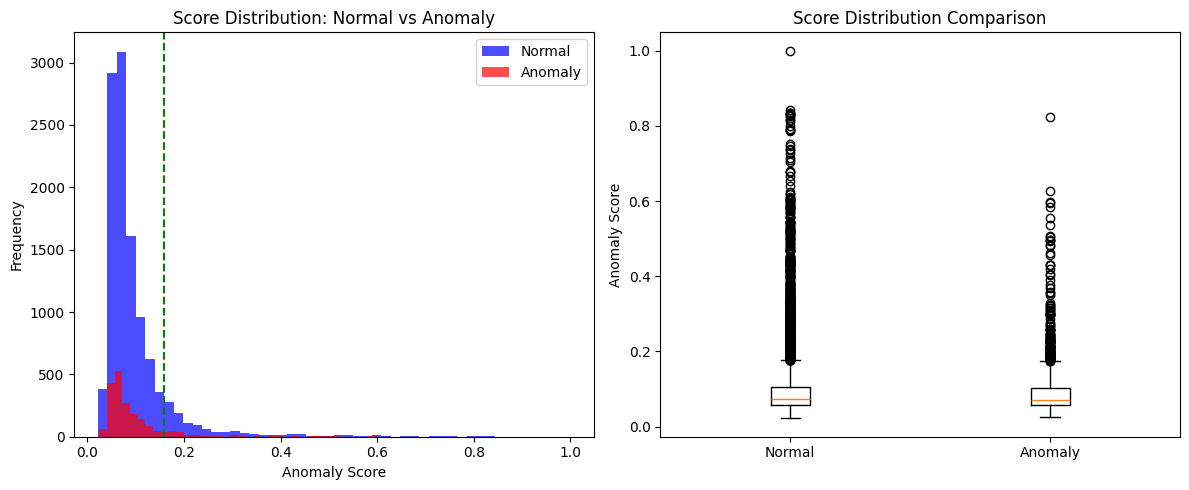

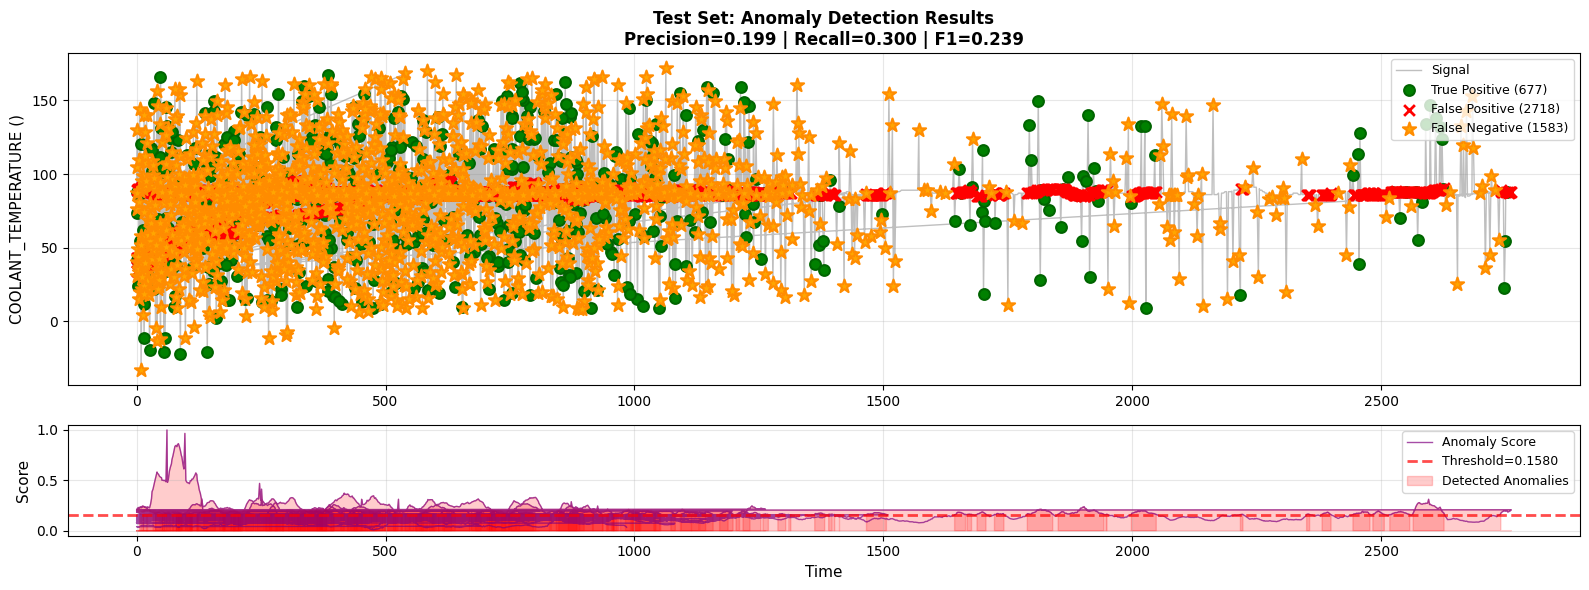


Detection Summary for COOLANT_TEMPERATURE ()
Total points: 11303
True anomalies: 2260 (20.0%)
Detected anomalies: 3395 (30.0%)

True Positives:  677
False Positives: 2718
False Negatives: 1583
True Negatives:  6325



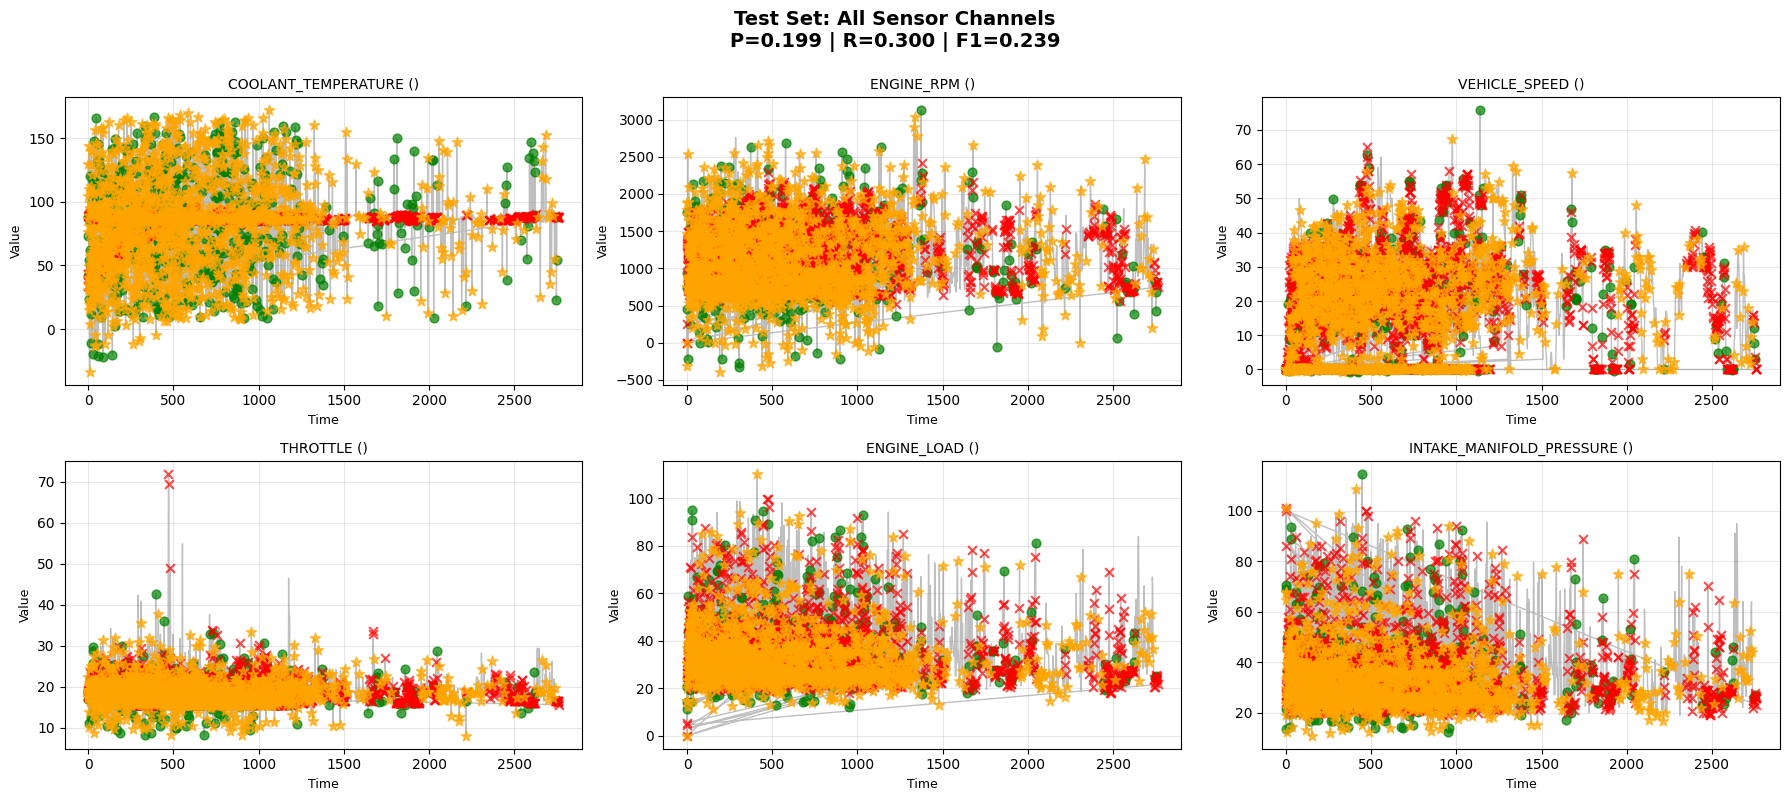


Confusion Matrix:
[[9936 1097]
 [1746  201]]
True Negatives: 9936, False Positives: 1097
False Negatives: 1746, True Positives: 201


In [ ]:
# %%
# Check score distributions
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


print("=== Anomaly Score Statistics ===")
print(f"Scores - Mean: {val_scores.mean():.4f}, Std: {val_scores.std():.4f}")
print(f"Scores - Min: {val_scores.min():.4f}, Max: {val_scores.max():.4f}")
print(f"True anomalies: {val_true_labels.sum()} / {len(val_true_labels)} ({val_true_labels.mean()*100:.1f}%)")

# %%
# Visualize score distributions for normal vs anomaly
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(val_scores[val_true_labels == 0], bins=50, alpha=0.7, label='Normal', color='blue')
plt.hist(val_scores[val_true_labels == 1], bins=50, alpha=0.7, label='Anomaly', color='red')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.title('Score Distribution: Normal vs Anomaly')
plt.legend()
plt.axvline(best_threshold, color='green', linestyle='--', label=f'Threshold={best_threshold:.4f}')

plt.subplot(1, 2, 2)
plt.boxplot([val_scores[val_true_labels == 0], val_scores[val_true_labels == 1]], 
            labels=['Normal', 'Anomaly'])
plt.ylabel('Anomaly Score')
plt.title('Score Distribution Comparison')

plt.tight_layout()
plt.show()

plot_detection_results(
    data_df=test_data_faulty,
    timestamps=test_data_faulty[time_col].values,
    true_labels=test_true_labels,
    predictions=test_preds,
    scores=test_scores,
    threshold=best_threshold,
    value_column="COOLANT_TEMPERATURE ()",
    title="Test Set: Anomaly Detection Results"
)

# %%
# Plot all channels
plot_multiple_channels(
    data_df=test_data_faulty,
    timestamps=test_data_faulty[time_col].values,
    true_labels=test_true_labels,
    predictions=test_preds,
    scores=test_scores,
    threshold=best_threshold,
    channels=target_columns,
    title="Test Set: All Sensor Channels"
)
# %%
# Check confusion matrix
preds = (val_scores > best_threshold).astype(int)
cm = confusion_matrix(val_true_labels, preds)
print("\nConfusion Matrix:")
print(cm)
print(f"True Negatives: {cm[0,0]}, False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}, True Positives: {cm[1,1]}")
